# Eval Overview - Gene Level Analysis

Our second eval category reviews our gene expression prediction from the perspective of the gene dimension. This eval runs on top of the predictions produced by the [linear expression decoder](https://github.com/GPTomics/biojepa/blob/main/layer_explainers/explainer_eval_decoders.ipynb). This analysis continues from the [Gene Expression Predictions](https://github.com/GPTomics/biojepa/blob/main/layer_explainers/explainer_eval_expr_prediction.ipynb) focusing on analyzing perturbation-level expression predictions from the gene axis.  

Our eval suite at the gene level analyzes relative expressions (over, under, no change) at the gene level for perturbations, and then differential gene expression ranking. As you walk through the notebook you'll see that we evaluate on multiple dimensions to ensure we have a thorough understanding on where our model is working well and where it's struggling.

In [1]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

In [2]:
SEED = 1337
np.random.seed(SEED)

## Data Prep
We'll start by preparing our data. For this evaluation, we need the average change in expression *expression delta* by perturbation.  

To get this we need to have the true cell expressions, the control expression for each cell, and the perturbation information. A "perturbation" is a unique combination of a sequence, target, modality, and mode applied to a cell type. A perturbation can span datasets. For the 6 samples we'll show the real control cell expression, predicted control cell expression (running the student encoder and then linear decoder), real case cell expression, predicted case cell expression, and the perturbation. 

For predicted expression, we use the data created by the [linear expression decoder](https://github.com/GPTomics/biojepa/blob/main/layer_explainers/explainer_eval_decoders.ipynb). As a reminder, the decoder takes the mean ($\mu$) BioJEPA-AC output based on the perturbations and cell expression pattern, and then uses a linear layer to project down to a $[\text{n\_genes},\text{1}]$ matrix with a single value per gene representing the expression.

After we stage the expression counts by sample, we'll calculate the expression delta by perturbation. This requires grouping our sample data by perturbation and taking the mean. With the staged data, you'll see that the first two samples share a perturbation as do our third and fourth sample.  

We'll stage data to show a few different predictions: a strong prediction, weak prediction, inverse prediction, and over prediction.

In [3]:
unique_perts = 4
num_genes = 8
num_cells = 6

**Perturbations**

We'll first start with our perturbations. Even though we have 6 cells, our sample will only have 4 unique perturbations. To define a unique perturbation, it's not just about what we target, but the context of it. Because of this, we represent a unique perturbation as $\text{(seq id, targ id, modality id, mode id, cell type)}$. IDs are used since our model keeps the perturbation information in separate caches from our sample expression counts to avoid heavy duplication of information.

We'll also create a mapping of the sample to the perturbation, where the first two samples map to the first perturbation, the next two samples to the second perturbation, and then the final two samples each have a unique perturbation.

In [4]:
pert_keys = [                                                                      
      (0, 0, 0, 0, 0),  # pert 0: DNA CRISPRi, cell type 0 
      (1, 1, 0, 0, 0),  # pert 1: DNA CRISPRi, cell type 0 
      (2, 2, 0, 1, 0),  # pert 2: DNA CRISPRa, cell type 0 
      (3, 3, 2, 4, 0),  # pert 3: Chemical inhibitor, cell type 0
]


sample_to_pert = [0, 0, 1, 1, 2, 3]

**Control Cells**

Next we'll show the control cell values. Recall that for our inference we pair together a perturbed cell with a random control cell from the same batch. This allows us to take an approximate change in prediction. Beyond just the control cell expression, to calculate our predicted change in expression, we run the expression predictor on the control cell's latent representation `z_context`. We'll discuss the calculation more but to show this we'll also have the predicted control expression.

For the predicted, we'll show a minor shift to highlight that often the prediction is not perfect.

In [5]:
real_control = np.array([
    [2.1, 3.4, 1.2, 4.1, 2.6, 3.1, 1.4, 4.6], 
    [1.9, 3.6, 0.8, 3.9, 2.4, 2.9, 1.6, 4.4], 
    [2.0, 3.3, 1.1, 4.2, 2.3, 3.2, 1.3, 4.3], 
    [2.2, 3.7, 0.9, 3.8, 2.7, 2.8, 1.7, 4.7], 
    [2.0, 3.5, 1.0, 4.0, 2.5, 3.0, 1.5, 4.5], 
    [2.0, 3.5, 1.0, 4.0, 2.5, 3.0, 1.5, 4.5], 
])
pred_control = np.array([
    [2.0, 3.3, 1.3, 4.0, 2.5, 3.2, 1.3, 4.5], 
    [1.8, 3.5, 0.9, 3.8, 2.3, 3.0, 1.5, 4.3], 
    [1.9, 3.2, 1.2, 4.1, 2.2, 3.3, 1.2, 4.2], 
    [2.1, 3.6, 1.0, 3.7, 2.6, 2.9, 1.6, 4.6], 
    [1.9, 3.4, 1.1, 3.9, 2.4, 3.1, 1.4, 4.4], 
    [1.9, 3.4, 1.1, 3.9, 2.4, 3.1, 1.4, 4.4], 
])
real_control.shape, pred_control.shape

((6, 8), (6, 8))

**Case Cell**

Next we'll show the case cell values. In our raw data we have the real expression of the perturbed cell. We pair this together with the linear expression decoder output based on the mean prediction, $\mu$, from the ACPredictor output. The mean prediction is based on the control cell latent representation `z_context` and the perturbations. You'll quickly be able to see that there is a difference between the real values and the predicted values. We've staged the data so that the first two samples predict closely, the next two samples weakly, the fifth sample predicts in the wrong direction, and the final sample over predicts. You'll see how these calculations flow through.

In [6]:
real_case = np.array([
    [2.8, 2.3, 1.6, 6.0, 2.0, 4.7, 1.2, 2.9], 
    [2.8, 2.2, 1.0, 6.0, 2.0, 4.3, 1.6, 2.5], 
    [2.1, 3.2, 1.2, 4.1, 2.4, 3.3, 1.3, 4.4], 
    [2.3, 3.6, 0.9, 3.7, 2.7, 2.8, 1.7, 4.7], 
    [2.5, 2.7, 1.6, 3.0, 2.8, 3.7, 1.1, 5.7], 
    [2.3, 3.1, 1.2, 4.5, 2.2, 3.6, 1.4, 4.9], 
])

pred_case = np.array([
    [2.6, 2.3, 1.8, 5.8, 2.0, 4.6, 1.0, 3.0],  # strong
    [2.6, 2.3, 1.2, 5.8, 2.0, 4.5, 1.4, 2.6],  # strong
    [2.05, 3.05, 1.25, 4.05, 2.3, 3.35, 1.15, 4.3],  # weak
    [2.15, 3.6, 0.95, 3.6, 2.65, 2.95, 1.6, 4.65],  # weak
    [1.6, 3.9, 1.6, 4.5, 2.2, 3.9, 1.7, 3.9],  # inverse
    [2.8, 2.2, 1.7, 5.4, 1.5, 4.9, 1.1, 5.6],  # over
])

real_case.shape, pred_case.shape

((6, 8), (6, 8))

**Calculate Sample Delta**

A major component of our expression benchmark is not looking at absolute predictions, but the change in expression. Some claim that this simplifies the task. Biologically, we see this as addressing the important questions: can you predict what will change, in what direction, and by how much. We focus on calculating two sample level differences:
1. `pred_delta` - the predicted change in expression as calculated by $\hat{\delta}_g = \hat{x}^{\text{case}}_g - \hat{x}^{\text{ctrl}}_g$. This value compares the predicted perturbed expression (`pred_case`) from the predicted control expression (`pred_control`). We use the predicted control expression to isolate BioJEPA-AC's learned perturbation effect from any baseline reconstruction error.
2. `real_delta` - the real change in expression as calculated by $\delta_g = x^{\text{case}}_g - x^{\text{ctrl}}_g$. This is our source of truth.

With this calculation you'll see how we end up seeing both increases and decreases in expression by gene. We'll end up comparing these by different slices in our calculations.

In [7]:
pred_delta = pred_case - pred_control

pred_delta.shape, pred_delta

((6, 8),
 array([[ 0.6 , -1.  ,  0.5 ,  1.8 , -0.5 ,  1.4 , -0.3 , -1.5 ],
        [ 0.8 , -1.2 ,  0.3 ,  2.  , -0.3 ,  1.5 , -0.1 , -1.7 ],
        [ 0.15, -0.15,  0.05, -0.05,  0.1 ,  0.05, -0.05,  0.1 ],
        [ 0.05,  0.  , -0.05, -0.1 ,  0.05,  0.05,  0.  ,  0.05],
        [-0.3 ,  0.5 ,  0.5 ,  0.6 , -0.2 ,  0.8 ,  0.3 , -0.5 ],
        [ 0.9 , -1.2 ,  0.6 ,  1.5 , -0.9 ,  1.8 , -0.3 ,  1.2 ]]))

In [8]:
real_delta = real_case - real_control

real_delta.shape, real_delta

((6, 8),
 array([[ 0.7, -1.1,  0.4,  1.9, -0.6,  1.6, -0.2, -1.7],
        [ 0.9, -1.4,  0.2,  2.1, -0.4,  1.4,  0. , -1.9],
        [ 0.1, -0.1,  0.1, -0.1,  0.1,  0.1,  0. ,  0.1],
        [ 0.1, -0.1,  0. , -0.1,  0. ,  0. ,  0. ,  0. ],
        [ 0.5, -0.8,  0.6, -1. ,  0.3,  0.7, -0.4,  1.2],
        [ 0.3, -0.4,  0.2,  0.5, -0.3,  0.6, -0.1,  0.4]]))

**Calculate Per-Perturbation Delta**

Now we'll calculate our per-perturbation data. We'll use our `sample_to_pert` to help identify which perturbation each sample belongs to. We'll iterate through our perturbations, find which samples belong to the perturbation, pluck out the expression data for the samples, and then run a mean across them to get a single value per perturbation.

In [9]:
mean_pert_pred_delta = np.zeros((unique_perts, num_genes)) 
mean_pert_real_delta = np.zeros((unique_perts, num_genes)) 

In [10]:
for pert_idx in range(unique_perts):                                            
    mask = [i for i, p in enumerate(sample_to_pert) if p == pert_idx]           
    mean_pert_pred_delta[pert_idx] = pred_delta[mask].mean(axis=0)                   
    mean_pert_real_delta[pert_idx] = real_delta[mask].mean(axis=0)
    
mean_pert_pred_delta.shape, mean_pert_pred_delta, mean_pert_real_delta

((4, 8),
 array([[ 0.7  , -1.1  ,  0.4  ,  1.9  , -0.4  ,  1.45 , -0.2  , -1.6  ],
        [ 0.1  , -0.075,  0.   , -0.075,  0.075,  0.05 , -0.025,  0.075],
        [-0.3  ,  0.5  ,  0.5  ,  0.6  , -0.2  ,  0.8  ,  0.3  , -0.5  ],
        [ 0.9  , -1.2  ,  0.6  ,  1.5  , -0.9  ,  1.8  , -0.3  ,  1.2  ]]),
 array([[ 0.8 , -1.25,  0.3 ,  2.  , -0.5 ,  1.5 , -0.1 , -1.8 ],
        [ 0.1 , -0.1 ,  0.05, -0.1 ,  0.05,  0.05,  0.  ,  0.05],
        [ 0.5 , -0.8 ,  0.6 , -1.  ,  0.3 ,  0.7 , -0.4 ,  1.2 ],
        [ 0.3 , -0.4 ,  0.2 ,  0.5 , -0.3 ,  0.6 , -0.1 ,  0.4 ]]))

## Gene Level Direction of Effect Analysis

Our first set of analysis at the gene level look to see if our delta correctly predicts the effect direction for a perturbation. We pick an arbitrary cutoff where we can separate our effect into: 
* down-regulated (below negative of our threshold value)
* up-regulated (above positive of our threshold value)
* no change (between the positive and negative of our threshold value)
This results in the following calculation:

$$
d(\delta_g) = \begin{cases} +1 & \text{if } \delta_g \geq \tau \\ -1 & \text{if } \delta_g \leq -\tau \\ 0 & \text{otherwise} \end{cases}
$$

Where $\tau = 0.25$ is the direction threshold and $\delta_g$ is the expression delta for gene g. For the direction of effect after classifying both the actual and predicted expression delta, we then run a number of different calculations. You might wonder why we picked 0.25. Our goal was to find a value where noisy changes that don't signify real movement don't drift the metric while real shifts in expression get captured. This does have a minor drawback where a gene with very low expression changes significantly (doubles or more) but because the initial expression was so low, we don't capture it. We're okay with this risk as we have other metrics to cover this analysis. *Note that if we wanted, we could change to fold-change where we look at the delta as a ratio to absolute expression.*

To start we'll run our classification on two different versions of our data: first all of the expression, and then only the top differentially expressed genes per perturbation.

In [11]:
threshold = 0.25

**Classify Direction All**

We'll first prep our data for all of the genes linked to a perturbation. We iterate perturbation by perturbation and numerically classify each gene into up ($+1$), down ($-1$), or no change ($0$). We'll do this for both the predicted delta and the real delta.

You'll see that our first perturbation (strong) classifies identically between predicted and real, our second perturbation (weak) correctly shows all zeros since the deltas are below our threshold, and our third perturbation (inverse) is where the direction errors start appearing. The fourth perturbation (over) mostly matches but over-classifies a few genes that the real deltas keep below threshold.

In [12]:
all_pred_dir = []
all_real_dir = []

In [13]:
for p in range(unique_perts):
    print(f'--- Pert {p} ---')
    delta = mean_pert_pred_delta[p]
    direction = np.zeros_like(delta, dtype=np.int8)
    direction[delta >= threshold] = 1
    direction[delta <= -threshold] = -1
    print(direction)
    all_pred_dir.append(direction)

all_pred_dir = np.concatenate(all_pred_dir)
all_pred_dir.shape, all_pred_dir

--- Pert 0 ---
[ 1 -1  1  1 -1  1  0 -1]
--- Pert 1 ---
[0 0 0 0 0 0 0 0]
--- Pert 2 ---
[-1  1  1  1  0  1  1 -1]
--- Pert 3 ---
[ 1 -1  1  1 -1  1 -1  1]


((32,),
 array([ 1, -1,  1,  1, -1,  1,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0, -1,
         1,  1,  1,  0,  1,  1, -1,  1, -1,  1,  1, -1,  1, -1,  1],
       dtype=int8))

In [14]:
for p in range(unique_perts):
    print(f'--- Pert {p} ---')
    delta = mean_pert_real_delta[p]
    direction = np.zeros_like(delta, dtype=np.int8)
    direction[delta >= threshold] = 1
    direction[delta <= -threshold] = -1
    print(direction)
    all_real_dir.append(direction)

all_real_dir = np.concatenate(all_real_dir)
all_real_dir.shape, all_real_dir

--- Pert 0 ---
[ 1 -1  1  1 -1  1  0 -1]
--- Pert 1 ---
[0 0 0 0 0 0 0 0]
--- Pert 2 ---
[ 1 -1  1 -1  1  1 -1  1]
--- Pert 3 ---
[ 1 -1  0  1 -1  1  0  1]


((32,),
 array([ 1, -1,  1,  1, -1,  1,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        -1,  1, -1,  1,  1, -1,  1,  1, -1,  0,  1, -1,  1,  0,  1],
       dtype=int8))

**Classify Direction Top 50 DEGs**

Next we'll run the same analysis but only on our top 50 differentially expressed genes. This reviews the real deltas to see which genes we expect to move the most by perturbation, largest $|\delta_{i,g}|$, and our analysis calculates how well we predict their directions. The value of focusing on top DEGs is that it strips away the easy "no change" majority and forces the model to prove it can get the direction right on genes that actually matter. If a model is just predicting no change for everything, this is where it gets caught.

For this example, since we only have 8 genes, instead of taking the top 50, we'll show it by taking only the top 3. You'll see that our third perturbation (inverse) now has all 3 directions wrong, making the errors much more visible than in the all-gene view where they were diluted by correct no-change predictions.

In [15]:
TOP_K = 3
top_deg_pred_dir = []
top_deg_real_dir = []

In [16]:
for p in range(unique_perts):
    print(f'--- Pert {p} ---')
    top_k_idx = np.argsort(np.abs(mean_pert_real_delta[p]))[-TOP_K:]
    delta = mean_pert_pred_delta[p][top_k_idx]
    direction = np.zeros_like(delta, dtype=np.int8)
    direction[delta >= threshold] = 1
    direction[delta <= -threshold] = -1
    print(direction)
    top_deg_pred_dir.append(direction)


top_deg_pred_dir = np.concatenate(top_deg_pred_dir)
top_deg_pred_dir.shape, top_deg_pred_dir

--- Pert 0 ---
[ 1 -1  1]
--- Pert 1 ---
[0 0 0]
--- Pert 2 ---
[ 1  1 -1]
--- Pert 3 ---
[1 1 1]


((12,), array([ 1, -1,  1,  0,  0,  0,  1,  1, -1,  1,  1,  1], dtype=int8))

In [17]:
for p in range(unique_perts):
    print(f'--- Pert {p} ---')
    top_k_idx = np.argsort(np.abs(mean_pert_real_delta[p]))[-TOP_K:]
    delta = mean_pert_real_delta[p][top_k_idx]
    direction = np.zeros_like(delta, dtype=np.int8)
    direction[delta >= threshold] = 1
    direction[delta <= -threshold] = -1
    print(direction)
    top_deg_real_dir.append(direction)

top_deg_real_dir = np.concatenate(top_deg_real_dir)
top_deg_real_dir.shape, top_deg_real_dir

--- Pert 0 ---
[ 1 -1  1]
--- Pert 1 ---
[0 0 0]
--- Pert 2 ---
[-1 -1  1]
--- Pert 3 ---
[1 1 1]


((12,), array([ 1, -1,  1,  0,  0,  0, -1, -1,  1,  1,  1,  1], dtype=int8))

### Directional Overall Accuracy
Our first set of calculations looks at the number of genes that are classified correctly. This calculation is a simple fraction of how many of the directions were predicted correctly. We calculate it as:

$$
\text{Direction Accuracy} = \frac{1}{P \cdot G} \sum_{p=1}^{P} \sum_{g=1}^{G} \mathbb{1}\left[d(\hat{\delta}_{p,g}) = d(\delta_{p,g})\right]
$$

Where $P$ is perturbations, $G$ is genes, and $d$ is the direction classification function. This gives us a quick, high-level sense of how frequently we are correct. The limitation of raw accuracy is that it treats every gene equally: getting the direction right on a gene that barely changes counts the same as getting it right on the most differentially expressed gene. It also doesn't tell us which direction we're struggling with. That's why we follow up with per-class F1 scores to break down performance by direction.

**All Genes**

We first analyze all of the genes. We have 32 gene classifications across our 4 perturbations so our accuracy will focus on how many are correct. You'll see that our first two perturbations (strong and weak) contribute zero errors, while the third (inverse) and fourth (over) perturbations each contribute errors. The errors land on exactly a quarter of our genes, resulting in a $0.75$ accuracy.

In [18]:
overall_accuracy = accuracy_score(all_real_dir, all_pred_dir)
overall_accuracy_ct = accuracy_score(all_real_dir, all_pred_dir, normalize=False)
len(all_real_dir), overall_accuracy_ct, overall_accuracy

(32, 24.0, 0.75)

**Top DEG**

We next analyze only our top differentially expressed genes. By taking the top 3 DEGs we now have 12 gene classifications across our 4 perturbations. You'll see that the same perturbations causing errors in the all-gene view (inverse and over) continue to cause errors here. Because of how we staged our data, the ratio of errors is maintained even when we focus on DEGs, giving us the same $0.75$ accuracy. In a real dataset, we'd expect this number to diverge from the all-gene accuracy since the no-change majority is removed.

In [19]:
top_deg_accuracy = accuracy_score(top_deg_real_dir, top_deg_pred_dir)
top_deg_accuracy_ct = accuracy_score(top_deg_real_dir, top_deg_pred_dir, normalize=False)
len(top_deg_real_dir), top_deg_accuracy_ct, top_deg_accuracy

(12, 9.0, 0.75)

### Single-Class F1 Score
Next we'll run single-class F1 calculations on all our gene deltas. The F1 score balances true positive accuracy (precision) and the ability to find all positive instances (recall) into a single score. We calculate F1 score as:
$$\begin{aligned}
\text{Precision}_{c} &= \frac{\sum_{p,g} \mathbb{1}[d(\hat{\delta}_{p,g}) = c \;\wedge\; d(\delta_{p,g}) = c]}{\sum_{p,g} \mathbb{1}[d(\hat{\delta}_{p,g}) = c]} \\
\\
\text{Recall}_{c} &= \frac{\sum_{p,g} \mathbb{1}[d(\hat{\delta}_{p,g}) = c \;\wedge\; d(\delta_{p,g}) = c]}{\sum_{p,g}\mathbb{1}[d(\delta_{p,g}) = c]} \\
F_{1,c} &= \frac{2 \cdot \text{Precision}_{c} \cdot \text{Recall}_{c}}{\text{Precision}_{c} + \text{Recall}_{c}}
\end{aligned}$$

Since we calculate single-class scores, we calculate three separate scores: f1_up $(c = +1)$, f1_down $(c = -1)$, f1_unchanged $(c = 0)$. The best way to think of the calculated components is: 
* precision: of the examples where the model predicted the expected class, how many are correct
* recall: of the examples that are expected to be in the class, how many did the model correctly predict being in it. 

By calculating three separate scores, we can see how well we're doing on each category of prediction to better understand what predictions our model does well. Because of how we staged our data and how typical models are structured, we expect that the models should do well on no change since that's the largest class and they'll do worse on the up-regulated or down-regulated F1.

**F1 Up $(c = +1)$** 

We'll start with up-regulation prediction. This compares the predicted up-regulation ($d = +1$) with the real up-regulated delta. Since our inverse perturbation flips several up-regulated genes to down-regulated in the prediction, we'd expect the up F1 to take a hit from both missed true positives and false positives.

In [20]:
f1_up = f1_score(all_real_dir, all_pred_dir, labels=[1], average='macro', zero_division=0)
f1_up

0.7407407407407407

**F1 Down $(c = -1)$**

Next we'll compare down-regulated prediction. This compares the predicted down-regulation ($d = -1$) with the real down-regulated delta. You'll see this F1 is lower than the up F1. The inverse perturbation hurts here too, and the over perturbation adds further confusion by predicting down-regulation on genes that don't actually cross our threshold.

In [21]:
f1_down = f1_score(all_real_dir, all_pred_dir, labels=[-1], average='macro', zero_division=0)
f1_down

0.625

**F1 Unchanged $(c = 0)$**

Finally we'll cover the no-change prediction. This compares the genes that are predicted not to change in expression ($d = 0$) with the real gene deltas that do not change. As we predicted in the F1 introduction, this should be our strongest F1 since the majority of genes don't change for any given perturbation, making "no change" the easiest class. You'll see it comes in well above the up and down F1 scores.

In [22]:
f1_unchanged = f1_score(all_real_dir, all_pred_dir, labels=[0], average='macro', zero_division=0)
f1_unchanged

0.8571428571428571

### Directional Top 20 DEG Precision
Our next analysis digs deeper into the precision of our predictions. As a reminder, precision is analyzing the examples where the model predicted the expected class, how many are correct. For our precision, we specifically look at two different calculations per perturbation: the precision of our top up-regulated genes and the precision of our down-regulated genes. We calculate it as:
$$
\text{Precision}^{r}_{k} = \frac{1}{P} \sum_{p=1}^{P} \frac{|\hat{S}^{r}_{p,k} \cap S^{r}_{p,k}|}{k}, \quad r \in \{\uparrow,\downarrow\}
$$
Where $S^{r}_{p,k}$ is the set of k genes with the largest (r=up) or most negative (r=down) true deltas for perturbation p, and $\hat{S}$ is the predicted counterpart. By comparing the precision we can see if the model is favoring either direction of change in our DEG analysis.  

Since this uses a unique way of differential expression binning, we'll cycle through our perturbation deltas, pull out the most up-regulated and down-regulated genes (we'll use K=2), and then calculate precision.

In [23]:
most_K = 2
up_precisions, down_precisions = [], []

In [24]:
for p in range(unique_perts):
    print(f'--- Pert {p} ---')
    real_d = mean_pert_real_delta[p]
    pred_d = mean_pert_pred_delta[p]

    real_up = set(np.argsort(real_d)[-most_K:])
    pred_up = set(np.argsort(pred_d)[-most_K:])
    up_prec = len(pred_up & real_up) / most_K
    print(f'up regulated gene index: real {set(map(int,real_up))} | pred {set(map(int,pred_up))} | prec {up_prec}')

    real_down = set(np.argsort(real_d)[:most_K])
    pred_down = set(np.argsort(pred_d)[:most_K])
    down_prec = len(pred_down & real_down) / most_K
    print(f'down regulated gene index: real {set(map(int,real_down))} | pred {set(map(int,pred_down))} | prec {down_prec}')

    
    up_precisions.append(up_prec)
    down_precisions.append(down_prec)

--- Pert 0 ---
up regulated gene index: real {3, 5} | pred {3, 5} | prec 1.0
down regulated gene index: real {1, 7} | pred {1, 7} | prec 1.0
--- Pert 1 ---
up regulated gene index: real {0, 7} | pred {0, 7} | prec 1.0
down regulated gene index: real {1, 3} | pred {1, 3} | prec 1.0
--- Pert 2 ---
up regulated gene index: real {5, 7} | pred {3, 5} | prec 0.5
down regulated gene index: real {1, 3} | pred {0, 7} | prec 0.0
--- Pert 3 ---
up regulated gene index: real {3, 5} | pred {3, 5} | prec 1.0
down regulated gene index: real {1, 4} | pred {1, 4} | prec 1.0


**Calculate directional precision** 

Now that we have the precision of each perturbation based on directional differential expression, we can calculate the average precision for each direction. We can see that our third perturbation is our main culprit impacting our accuracy and the down-regulation impact is stronger.

In [25]:
prec_up_k = float(np.mean(up_precisions))
prec_up_k

0.875

In [26]:
prec_down_k = float(np.mean(down_precisions))
prec_down_k

0.75

### Jaccard Index (Differential Expression Set Overlap)

Our next differential expression analysis reviews if our model can correctly predict which genes are differentially expressed for each perturbation. For this, we use our threshold to determine if a gene is differentially expressed. We then compare the genes that we predict outside the threshold with the real genes with expression deltas outside the threshold to calculate the overlap using the Jaccard index:

$$
J_{p} = \frac{|\hat{E}_{p} \cap E_{p}|}{|\hat{E}_{p} \cup E_{p}|}
$$

where $E_{p} = \{g : |\delta_{p,g}| > \tau\}$ is the set of truly differentially expressed genes for perturbation p, and $\hat{E}_{p}$ is the predicted counterpart. 

We take the mean and median across the dataset since the distribution can be skewed by perturbations with very few DEGs where a single missed gene has an outsized effect on the ratio.

We'll first calculate the Jaccard index for each perturbation. You'll see that on our second perturbation, we actually have no DEGs since the perturbation impact is purposefully minimal. On the third you'll see the downside of focusing on direction-less DEGs, since we get a high Jaccard index but a low precision.

In [27]:
de_jaccards = []

In [28]:
for p in range(unique_perts):
    print(f'--- Pert {p} ---')
    real_d = mean_pert_real_delta[p]
    pred_d = mean_pert_pred_delta[p]
    
    real_de = set(np.where(np.abs(real_d) > threshold)[0])
    pred_de = set(np.where(np.abs(pred_d) > threshold)[0])
    union = len(pred_de | real_de)
    inner_join = len(pred_de & real_de)
    print(f'DE gene index: real {set(map(int,real_de))} | pred {set(map(int,pred_de))} | overlap {inner_join} | total {union}')
    
    if union > 0:
        de_jaccards.append(inner_join / union)

de_jaccards

--- Pert 0 ---
DE gene index: real {0, 1, 2, 3, 4, 5, 7} | pred {0, 1, 2, 3, 4, 5, 7} | overlap 7 | total 7
--- Pert 1 ---
DE gene index: real set() | pred set() | overlap 0 | total 0
--- Pert 2 ---
DE gene index: real {0, 1, 2, 3, 4, 5, 6, 7} | pred {0, 1, 2, 3, 5, 6, 7} | overlap 7 | total 8
--- Pert 3 ---
DE gene index: real {0, 1, 3, 4, 5, 7} | pred {0, 1, 2, 3, 4, 5, 6, 7} | overlap 6 | total 8


[1.0, 0.875, 0.75]

**Jaccard Mean/Median**  

Now that we have our per-perturbation Jaccard index calculated we can condense it down to a mean/median to better understand how this analysis distributes on our dataset. In a real dataset, we'd expect the median to be above the mean since most perturbations should have reasonable overlap, with a few poor predictions pulling the mean down. For our small staged dataset, they're equal given we only have 3 values that are evenly spaced. The $0.875$ tells us the model is identifying the right DE genes most of the time, even when it gets their directions wrong (as we saw with our third perturbation).

In [29]:
jaccard_mean = float(np.mean(de_jaccards))
jaccard_mean

0.875

In [30]:
jaccard_median = float(np.median(de_jaccards))
jaccard_median

0.875

### Bin Accuracy

Our final gene-level accuracy analysis is an error analysis based on the expression delta to help us troubleshoot directional prediction errors. Binning by real delta magnitude lets us see if the model's errors are uniform or if it struggles more on genes with large vs small expression changes. We calculate each bin's overall accuracy as:

$$
\text{Acc}_{b} = \frac{\sum_{p,g} \mathbb{1}[d(\hat{\delta}_{p,g}) = d(\delta_{p,g})] \cdot \mathbb{1}[|\delta_{p,g}| \in B_{b}]}{\sum_{p,g} \mathbb{1}[|\delta_{p,g}| \in B_{b}]}
$$

Where the bins are $B = \{[0, 0.25), [0.25, 0.5), [0.5, 1.0), [1.0, 1.5), [1.5, 2.0), [2.0, \infty)\}$. Because of how we structured our data, we'll see most of the errors lie in the middle of our bins. Typically we would dig in and see if the error is mainly because our model isn't bold enough, or if there's some other issues causing it. This analysis can also let us understand how to select our threshold, if it needs to increase or decrease. 

We start first by calculating which genes we predict correctly and their corresponding magnitude.

In [31]:
all_magnitudes = np.abs(np.concatenate(mean_pert_real_delta))
all_magnitudes.shape, all_magnitudes

((32,),
 array([0.8 , 1.25, 0.3 , 2.  , 0.5 , 1.5 , 0.1 , 1.8 , 0.1 , 0.1 , 0.05,
        0.1 , 0.05, 0.05, 0.  , 0.05, 0.5 , 0.8 , 0.6 , 1.  , 0.3 , 0.7 ,
        0.4 , 1.2 , 0.3 , 0.4 , 0.2 , 0.5 , 0.3 , 0.6 , 0.1 , 0.4 ]))

In [32]:
all_correct = np.array(all_real_dir == all_pred_dir)
all_correct.shape, all_correct

((32,),
 array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True, False, False,
         True, False, False,  True, False, False,  True,  True, False,
         True,  True,  True, False,  True]))

**Calculate Bin Accuracy**

Now we'll go through each bin, select the genes that fit into the bin based on the real expression delta, and then calculate the overall accuracy. This will show us both how many expressions are in each bin, and how well we did. If we see an exceptionally low count in a specific bin, the model may have trouble learning it and that could be a cause for low accuracy. 

In [33]:
magnitude_bins = [0, 0.25, 0.5, 1.0, 1.5, 2.0, np.inf]
bin_labels = ['0-0.25', '0.25-0.5', '0.5-1.0', '1.0-1.5', '1.5-2.0', '2.0+']
accuracy_by_magnitude = {}

In [34]:
for i in range(len(magnitude_bins) - 1):
    print(f'Bin {i}:{magnitude_bins[i]}')
    mask = (all_magnitudes >= magnitude_bins[i]) & (all_magnitudes < magnitude_bins[i + 1])
    print(mask)
    if mask.sum() > 0:
        accuracy_by_magnitude[bin_labels[i]] = {'accuracy': float(all_correct[mask].mean()), 'count': int(mask.sum())}

Bin 0:0
[False False False False False False  True False  True  True  True  True
  True  True  True  True False False False False False False False False
 False False  True False False False  True False]
Bin 1:0.25
[False False  True False False False False False False False False False
 False False False False False False False False  True False  True False
  True  True False False  True False False  True]
Bin 2:0.5
[ True False False False  True False False False False False False False
 False False False False  True  True  True False False  True False False
 False False False  True False  True False False]
Bin 3:1.0
[False  True False False False False False False False False False False
 False False False False False False False  True False False False  True
 False False False False False False False False]
Bin 4:1.5
[False False False False False  True False  True False False False False
 False False False False False False False False False False False False
 False False False Fa

{'0-0.25': {'accuracy': 0.8181818181818182, 'count': 11}, '0.25-0.5': {'accuracy': 0.7142857142857143, 'count': 7}, '0.5-1.0': {'accuracy': 0.75, 'count': 8}, '1.0-1.5': {'accuracy': 0.3333333333333333, 'count': 3}, '1.5-2.0': {'accuracy': 1.0, 'count': 2}, '2.0+': {'accuracy': 1.0, 'count': 1}}


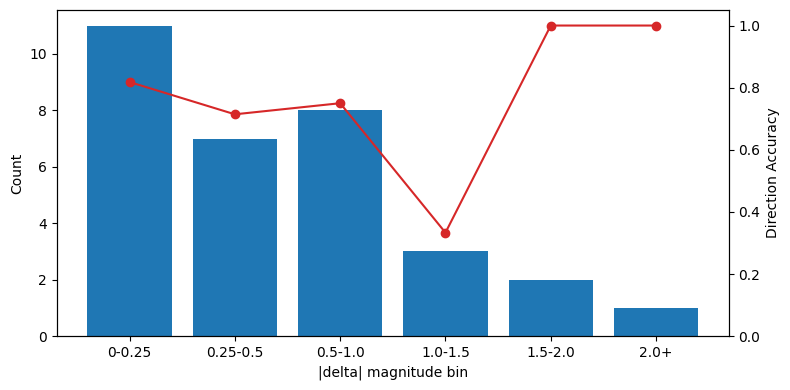

In [35]:
def plot_accuracy_by_magnitude(bin_data):                                                                                           
      fig, ax1 = plt.subplots(figsize=(8, 4))                                               
      labels, accs, counts = zip(*[(k, d['accuracy'], d['count']) for k, d in bin_data.items()])                                      
      x = range(len(labels))                                                                                                          
      ax1.bar(x, counts)                                                                                                              
      ax1.set(xlabel='|delta| magnitude bin', ylabel='Count')                               
      ax1.set_xticks(x, labels)
      ax2 = ax1.twinx()
      ax2.plot(x, accs, marker='o', color='tab:red')
      ax2.set(ylabel='Direction Accuracy', ylim=(0, 1.05))
      plt.tight_layout()
    
print(accuracy_by_magnitude)
plot_accuracy_by_magnitude(accuracy_by_magnitude)

## Differentially Expressed Genes

Our next set of analyses compares the rank order of the differential expression of genes. For this set of analysis, we rank genes based on their relative order of the absolute value of the expression delta. Once we have the order we perform a series of different statistical analyses on the top K amount of genes. In our production analysis, we use a series of different "K" (10, 20, 50, 100) to see how our metrics change as we relax constraint. We should expect that the metrics improve the wider net we cast. Even at 100, when we have 10K genes we're still looking at the top 1% of genes. 

For our evaluation, we'll just use two top K values: 2, and 4 just to show how the values can change. We'll first start by getting our absolute ranks for both our prediction delta and gene deltas. We'll do our calculations a bit different than the evals to highlight the specific statistics calculated.

In [36]:
K_VALUES = [2,4]

**Data Prep**  

Our first step will be to get the positional index sorted by the differential gene expression amount. We'll do this sorting by perturbation and we'll independently sort both the predicted delta and the real delta. These values will then become our inputs to each benchmark comparison. If you look closely you'll see that our orderings don't quite match up for any of our values.  This is purposeful to show the different evaluations. 

In [37]:
pred_rank = []
true_rank = []

In [38]:
for p in range(unique_perts):
    true_rank.append(np.argsort(np.abs(mean_pert_real_delta[p]))[::-1])
    pred_rank.append(np.argsort(np.abs(mean_pert_pred_delta[p]))[::-1])
true_rank, pred_rank

([array([3, 7, 5, 1, 0, 4, 2, 6]),
  array([3, 1, 0, 7, 4, 2, 5, 6]),
  array([7, 3, 1, 5, 2, 0, 6, 4]),
  array([5, 3, 7, 1, 4, 0, 2, 6])],
 [array([3, 7, 5, 1, 0, 2, 4, 6]),
  array([0, 7, 1, 3, 4, 5, 6, 2]),
  array([5, 3, 7, 2, 1, 6, 0, 4]),
  array([5, 3, 1, 7, 4, 0, 2, 6])])

### Precision @ K
Our first evaluation is precision at the different K levels. As a reminder, precision is analyzing how many of our predictions are accurate. We calculate this as:
$$
\text{Precision}_{k} = \frac{1}{P} \sum_{p=1}^{P} \frac{|\hat{T}_{p,k} \cap T_{p,k}|}{k}
$$

where $T_{p,k}$ is the set of k genes with the largest $|\delta_{p,g}|$ for perturbation p, and $\hat{T}_{p,k}$ is the predicted counterpart computed across our set $k$, in this case 2 and 4.  This is the same as previous precision that we've calculated except that we're looking at our expression ranked by absolute delta magnitude instead of direction.   You'll notice that because of how we setup our data you'll see a large jump as we increase $k$. 

In [39]:
deg_precision = {k: [] for k in K_VALUES}
deg_precision_mean = {}
deg_precision, deg_precision_mean

({2: [], 4: []}, {})

In [40]:
for k in K_VALUES:
    print(f'--- K {k} ---')
    for p in range(unique_perts):
        pred = set(pred_rank[p][:k])
        true = set(true_rank[p][:k])
        overlap = len(pred & true)
        precision = overlap / k
        deg_precision[k].append(precision)
        print(f'  Pert {p} precision: overlap {overlap} | total {k} | precision {precision}')
deg_precision   

--- K 2 ---
  Pert 0 precision: overlap 2 | total 2 | precision 1.0
  Pert 1 precision: overlap 0 | total 2 | precision 0.0
  Pert 2 precision: overlap 1 | total 2 | precision 0.5
  Pert 3 precision: overlap 2 | total 2 | precision 1.0
--- K 4 ---
  Pert 0 precision: overlap 4 | total 4 | precision 1.0
  Pert 1 precision: overlap 4 | total 4 | precision 1.0
  Pert 2 precision: overlap 3 | total 4 | precision 0.75
  Pert 3 precision: overlap 4 | total 4 | precision 1.0


{2: [1.0, 0.0, 0.5, 1.0], 4: [1.0, 1.0, 0.75, 1.0]}

In [41]:
for k in K_VALUES:
    mean = float(np.mean(deg_precision[k]))
    deg_precision_mean[k] = mean
deg_precision_mean

{2: 0.625, 4: 0.9375}

### Normalized Discounted Cumulative Gain (NDCG) @ K
While precision focuses on whether the right genes appear in the top k, Normalized Discounted Cumulative Gain (NDCG) focuses on their ranking order. NDCG analyses if a gene that is truly the most differentially expressed appears near the top of the predicted ranking. NDCG penalizes relevant genes appearing lower in the ranking using logarithmic discounting: 
$$\begin{aligned}
\text{NDCG}_{k} &= \frac{1}{P} \sum_{p=1}^{P} \frac{\text{DCG}_{p,k}}{\text{IDCG}_{k}}  \\
\\
\text{DCG}_{p,k} &= \sum_{i=1}^{k} \frac{\mathbb{1}[\hat{T}_{p,k}(i) \in T_{p,k}]}{\log_{2}(i+1)}
\end{aligned}$$

where $\hat{T}_{p,k}(i)$ is the gene at position $i$ in the predicted ranking by $|\hat{\delta}_{p,g}|$, $T_{p,k}$ is the true top-k set by $|\delta_{p,g}|$, and $\text{IDCG}_{k}$ is the Ideal DCG when all $k$ relevant genes appear at the top positions. 

A score of 1.0 means the predicted ranking perfectly recovers the true top-k in the correct order, while a lower score means relevant genes are either missing or ranked too low. For NDCG you'll see that we have to keep our predicted ordering in place for our evaluation as we need to calculate the discounted ranking. You can see how on our second and third perturbation expanding K recovers the NDCG.

In [42]:
deg_ndcg = {k: [] for k in K_VALUES}
deg_ndcg_mean = {}
deg_ndcg, deg_ndcg_mean

({2: [], 4: []}, {})

In [43]:
for k in K_VALUES:
    print(f'--- K {k} ---')
    for p in range(unique_perts):
        true = set(true_rank[p][:k])
        pred = pred_rank[p][:k]  # we have to keep as a list to preserve ordering. 
        rels = [1 if g in true else 0 for g in pred]
        dcg = sum(r / np.log2(i + 2) for i, r in enumerate(rels))
        idcg = sum(1 / np.log2(i + 2) for i in range(min(k, len(true))))
        ndcg = dcg / idcg if idcg > 0 else 0.0
        deg_ndcg[k].append(ndcg)
        print(f'  Pert {p} NDCG: rels {rels} | dcg {dcg} | idcg {idcg} | ndcg {ndcg}')
deg_ndcg

--- K 2 ---
  Pert 0 NDCG: rels [1, 1] | dcg 1.6309297535714575 | idcg 1.6309297535714575 | ndcg 1.0
  Pert 1 NDCG: rels [0, 0] | dcg 0.0 | idcg 1.6309297535714575 | ndcg 0.0
  Pert 2 NDCG: rels [0, 1] | dcg 0.6309297535714575 | idcg 1.6309297535714575 | ndcg 0.38685280723454163
  Pert 3 NDCG: rels [1, 1] | dcg 1.6309297535714575 | idcg 1.6309297535714575 | ndcg 1.0
--- K 4 ---
  Pert 0 NDCG: rels [1, 1, 1, 1] | dcg 2.5616063116448506 | idcg 2.5616063116448506 | ndcg 1.0
  Pert 1 NDCG: rels [1, 1, 1, 1] | dcg 2.5616063116448506 | idcg 2.5616063116448506 | ndcg 1.0
  Pert 2 NDCG: rels [1, 1, 1, 0] | dcg 2.1309297535714578 | idcg 2.5616063116448506 | ndcg 0.8318724637288826
  Pert 3 NDCG: rels [1, 1, 1, 1] | dcg 2.5616063116448506 | idcg 2.5616063116448506 | ndcg 1.0


{2: [np.float64(1.0),
  np.float64(0.0),
  np.float64(0.38685280723454163),
  np.float64(1.0)],
 4: [np.float64(1.0),
  np.float64(1.0),
  np.float64(0.8318724637288826),
  np.float64(1.0)]}

In [44]:
for k in K_VALUES:
    mean = float(np.mean(deg_ndcg[k]))
    deg_ndcg_mean[k] = mean
deg_ndcg_mean

{2: 0.5967132018086354, 4: 0.9579681159322206}

### Overlap @ K

Our last metric is simply the number of genes that appear in both the predicted and true top-k sets. Where precision normalizes this by $k$ to give a fraction, overlap reports the average based on the absolute number of shared genes:
$$
\text{Overlap}_{k} = \frac{1}{P} \sum_{p=1}^{P} |\hat{T}_{p,k} \cap T_{p,k}|
$$

To help contextualize the overlap, we also report a ratio that compares our overlap to what we'd expect from randomly selecting $k$ genes out of our full gene set:
$$
\text{overlap\_vs\_random}_{k} = \frac{\text{Overlap}_{k}}{k^{2} / G}
$$

where $G$ is the total number of genes. 

When the multiple compared to random is 1.0, this means it's equal to chance so the goal is the higher the better. 

In [45]:
deg_overlap = {k: [] for k in K_VALUES}
deg_overlap_mean = {}
deg_overlap_chance = {}
deg_overlap, deg_overlap_mean, deg_overlap_chance

({2: [], 4: []}, {}, {})

In [46]:
for k in K_VALUES:
    print(f'--- K {k} ---')
    for p in range(unique_perts):
        true = set(true_rank[p][:k])
        pred = set(pred_rank[p][:k])
        both = len(pred & true)
        deg_overlap[k].append(both)
        print(f'  Pert {p} Overlap: both {both} | all {k}')
deg_overlap   

--- K 2 ---
  Pert 0 Overlap: both 2 | all 2
  Pert 1 Overlap: both 0 | all 2
  Pert 2 Overlap: both 1 | all 2
  Pert 3 Overlap: both 2 | all 2
--- K 4 ---
  Pert 0 Overlap: both 4 | all 4
  Pert 1 Overlap: both 4 | all 4
  Pert 2 Overlap: both 3 | all 4
  Pert 3 Overlap: both 4 | all 4


{2: [2, 0, 1, 2], 4: [4, 4, 3, 4]}

In [47]:
for k in K_VALUES:
    mean = float(np.mean(deg_overlap[k]))
    deg_overlap_mean[k] = mean
deg_overlap_mean

{2: 1.25, 4: 3.75}

**Versus chance**

Now that we have the overlap, we can compare it to chance.  The chance would be the ratio of the probability that we'd pull the value out of the set given $k$ pulls resulting in $\frac{\text{Overlap}_{k}}{k^{2} / G}$.  As you'll see, in both our cases we do better than chance, though, interestingly, when we increase our $k$ our chance decreases.  This is because the larger the $k$ is in comparison to our total genes, the easier it is to get the values by chance. 

In [48]:
for k in K_VALUES:
    mean = deg_overlap_mean[k]
    chance = mean / (k * k / num_genes)
    deg_overlap_chance[k] = chance
deg_overlap_chance

{2: 2.5, 4: 1.875}

## Gene Analysis Final Wrapup
We've now walked through our evaluation at the gene level for our perturbation expression deltas. As you can see we run a number of different evaluations that help tell us where our prediction is working well and where it is not. By focusing on expression deltas for this analysis we can begin to understand how well our model predicts over expression, under expression, and no changes. You can see our application of coarse classifications to see how our model does directionally. Overall, by looking at the directions and ordinal DEG representations, we are starting to put the model through a harder set of evals to see if it is learning true gene regulatory networks and the physics of cells. In our production eval we also run these analyses with the exact same calculation but subgrouping by dataset.